# 🏆 Transform × Model Karşılaştırma Çalışması
**Soru:** Hedef değişkene hangi transform + hangi model kombinasyonu en iyi sonucu verir?  
**Yöntem:** 6 transform × 8 model (+ Stacking) = 48 kombinasyon, 5-fold CV ile RMSE  

| Transform | Açıklama |
|-----------|----------|
| None | Baseline — hiç transform yok |
| Log | np.log1p — klasik, yorumlanabilir |
| Sqrt | np.sqrt — hafif düzeltme |
| Cbrt | np.cbrt — küp kök |
| Box-Cox | scipy — matematiksel optimum |
| Yeo-Johnson | sklearn — negatif değerleri de kaldırır |

## 0. Kurulum

In [1]:
pip install pandas numpy matplotlib seaborn scipy scikit-learn xgboost lightgbm

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 2.1 MB/s eta 0:00:49
   ---------------------------------------- 1.0/101.7 MB 2.4 MB/s eta 0:00:43
    --------------------------------------- 2.1/101.7 MB 3.4 MB/s eta 0:00:30
   - -------------------------------------- 2.9/101.7 MB 3.2 MB/s eta 0:00:31
   - -------------------------------------- 3.9/101.7 MB 3.6 MB/s eta 0:00:28
   - -------------------------------------- 4.7/101.7 MB 3.6 MB/s eta 0:00:27
   -- ------------------------------------- 5.8/101.7 MB 3.8 MB/s eta 0:00:26
   -- ------------------------------------- 6.6/101.7 MB 3.9 MB/s eta 0:00:25
   -- ------------------------------------- 7.6/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 8.4/101.7 MB 3.9 MB/s eta 0:00:24
   --- ------------------------------------ 8.9/101.7 MB 3.8 MB/s eta 0:00:25



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.special import inv_boxcox

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.preprocessing import PowerTransformer, LabelEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

PROJECT_ROOT = Path().resolve().parent
DATA_RAW     = PROJECT_ROOT / 'data' / 'raw'
DATA_PROC    = PROJECT_ROOT / 'data' / 'processed'
DATA_PROC.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
#dark mode için
plt.rcParams.update({
    'figure.facecolor' : '#0f1117',
    'axes.facecolor'   : '#1a1d27',
    'axes.edgecolor'   : '#3a3d4d',
    'axes.labelcolor'  : '#e0e0e0',
    'xtick.color'      : '#b0b0b0',
    'ytick.color'      : '#b0b0b0',
    'text.color'       : '#e0e0e0',
    'grid.color'       : '#2a2d3d',
    'grid.alpha'       : 0.5,
})

PALETTE = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']
# 'None (Baseline)' → '#e74c3c'  (kırmızı)
# 'Log (log1p)'     → '#3498db'  (mavi)
# 'Sqrt'            → '#2ecc71'  (yeşil)
# 'Cbrt'            → '#f39c12'  (turuncu)
# 'Box-Cox'         → '#9b59b6'  (mor)
# 'Yeo-Johnson'     → '#1abc9c'  (turkuaz)
print('Kutuphaneler yuklendi')
print(f'Proje root: {PROJECT_ROOT}')

Kutuphaneler yuklendi
Proje root: C:\Users\Yousuf pc\Desktop\çalışmalarım\End-to-End Tabular ML Pipeline


## 1. Veri Yükleme ve Ön İşleme

In [ ]:
train = pd.read_csv(DATA_RAW / 'train.csv')
train = train.drop(
    train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 200000)].index
)# outliers
print(f'Shape: {train.shape}')

def quick_preprocess(df):
    df = df.copy()
    df['TotalSF']        = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalBathrooms'] = df['FullBath'] + 0.5*df['HalfBath'] + df['BsmtFullBath'] + 0.5*df['BsmtHalfBath']
    df['HouseAge']       = df['YrSold'] - df['YearBuilt']
    df['RemodAge']       = df['YrSold'] - df['YearRemodAdd']
    df['IsRemodeled']    = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)
    df['HasGarage']      = (df['GarageArea'] > 0).astype(int)
    df['HasPool']        = (df['PoolArea']   > 0).astype(int)
    df['HasFireplace']   = (df['Fireplaces'] > 0).astype(int)

    cat_none = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
                'GarageType','GarageFinish','GarageQual','GarageCond',
                'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1',
                'BsmtFinType2','MasVnrType']
    for c in cat_none:
        if c in df.columns: df[c] = df[c].fillna('None')

    num_zero = ['GarageYrBlt','GarageArea','GarageCars','BsmtFinSF1',
                'BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','MasVnrArea',
                'BsmtFullBath','BsmtHalfBath']
    for c in num_zero:
        if c in df.columns: df[c] = df[c].fillna(0)

    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )
    for c in df.select_dtypes('object').columns:
        df[c] = df[c].fillna(df[c].mode()[0])
    for c in df.select_dtypes('number').columns:
        df[c] = df[c].fillna(df[c].median())
    for c in df.select_dtypes('object').columns:
        df[c] = LabelEncoder().fit_transform(df[c].astype(str))
    return df

processed = quick_preprocess(train)
X = processed.drop(columns=['SalePrice','Id']).values
y = processed['SalePrice'].values
print(f'X: {X.shape}  |  y mean: ${y.mean():,.0f}')

Shape: (1458, 81)
X: (1458, 87)  |  y mean: $180,933


## 2. Transform Görsel Karşılaştırması

In [4]:
y_bc, bc_lambda = stats.boxcox(y)
pt_yj = PowerTransformer(method='yeo-johnson', standardize=False)
y_yj  = pt_yj.fit_transform(y.reshape(-1,1)).ravel()

TRANSFORMS = {
    'None (Baseline)' : y,
    'Log (log1p)'     : np.log1p(y),
    'Sqrt'            : np.sqrt(y),
    'Cbrt'            : np.cbrt(y),
    'Box-Cox'         : y_bc,
    'Yeo-Johnson'     : y_yj,
}

print(f'{"Transform":<20} {"Skewness":>10}  Degerlendirme')
print('-'*55)
for name, vals in TRANSFORMS.items():
    skew = pd.Series(vals).skew()
    tag  = 'Iyi' if abs(skew)<0.5 else ('Orta' if abs(skew)<1 else 'Kotu')
    print(f'{name:<20} {skew:>+10.3f}  {tag}')

Transform              Skewness  Degerlendirme
-------------------------------------------------------
None (Baseline)          +1.881  Kotu
Log (log1p)              +0.122  Iyi
Sqrt                     +0.942  Orta
Cbrt                     +0.666  Orta
Box-Cox                  -0.009  Iyi
Yeo-Johnson              -0.009  Iyi


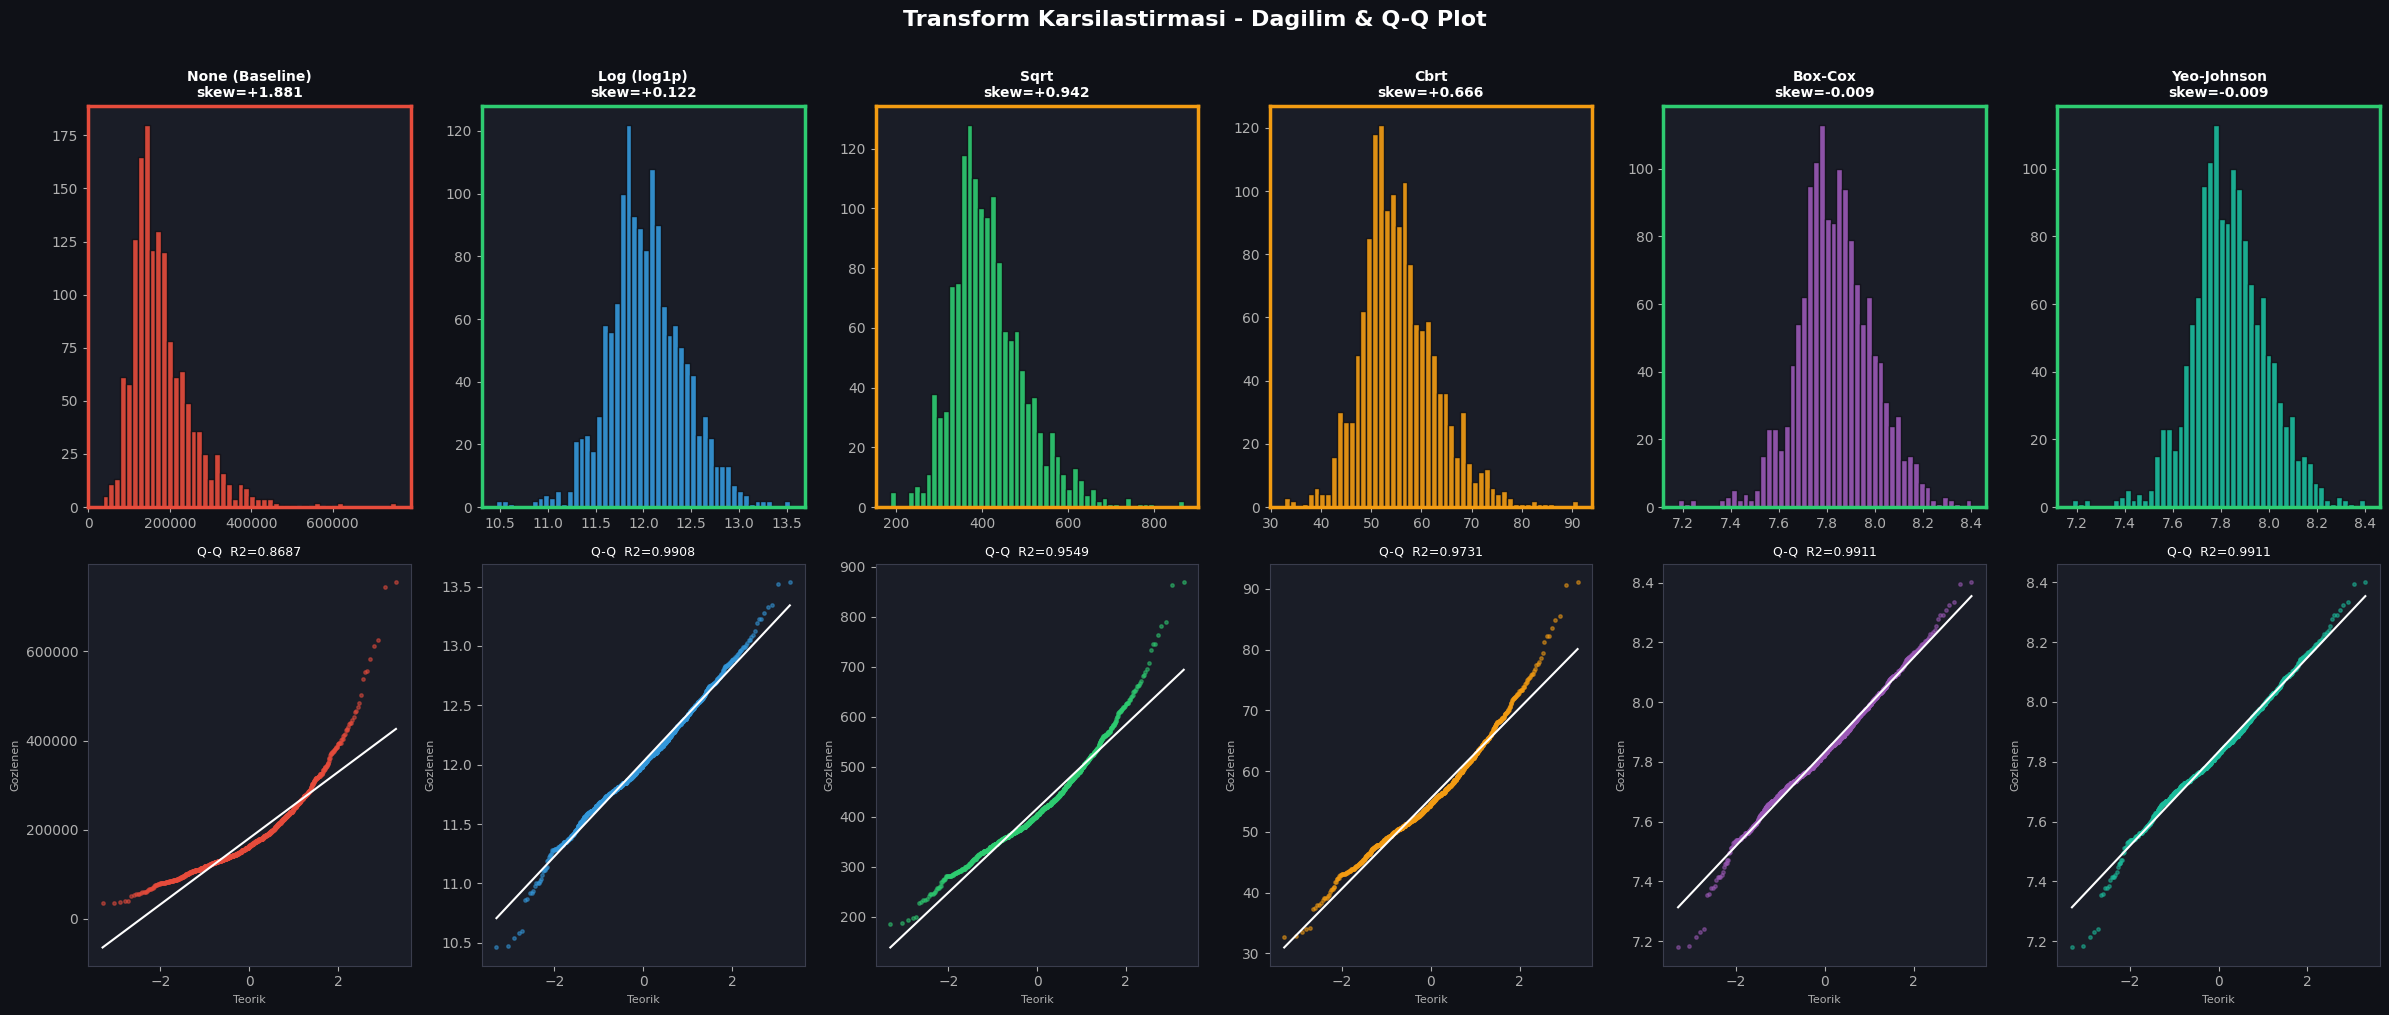

Yesil border = skew < 0.5 (iyi) | Turuncu = orta | Kirmizi = kotu


In [5]:
fig = plt.figure(figsize=(24, 10), facecolor='#0f1117')
fig.suptitle('Transform Karsilastirmasi - Dagilim & Q-Q Plot',
             fontsize=16, fontweight='bold', color='white', y=1.01)

n = len(TRANSFORMS)
for i, (name, vals) in enumerate(TRANSFORMS.items()):
    skew      = pd.Series(vals).skew()
    col       = PALETTE[i]
    border_col = '#2ecc71' if abs(skew)<0.5 else ('#f39c12' if abs(skew)<1 else '#e74c3c')

    ax1 = fig.add_subplot(2, n, i+1)
    ax1.hist(vals, bins=50, color=col, edgecolor='#0f1117', alpha=0.9)
    ax1.set_title(f'{name}\nskew={skew:+.3f}', color='white', fontsize=10, fontweight='bold')
    ax1.set_facecolor('#1a1d27')
    for sp in ax1.spines.values():
        sp.set_edgecolor(border_col)
        sp.set_linewidth(2.5)

    ax2 = fig.add_subplot(2, n, i+1+n)
    (osm, osr), (slope, intercept, r) = stats.probplot(vals)
    ax2.scatter(osm, osr, color=col, s=6, alpha=0.5)
    line_x = np.array([osm.min(), osm.max()])
    ax2.plot(line_x, slope*line_x + intercept, 'white', lw=1.5)
    ax2.set_title(f'Q-Q  R2={r**2:.4f}', color='white', fontsize=9)
    ax2.set_facecolor('#1a1d27')
    ax2.set_xlabel('Teorik', color='#b0b0b0', fontsize=8)
    ax2.set_ylabel('Gozlenen', color='#b0b0b0', fontsize=8)
    for sp in ax2.spines.values(): sp.set_edgecolor('#3a3d4d')

plt.tight_layout()
plt.savefig(DATA_PROC / '01_transform_distributions.png',
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Yesil border = skew < 0.5 (iyi) | Turuncu = orta | Kirmizi = kotu')

## 3. Model Tanımları (Stacking dahil)

In [6]:
base_estimators = [
    ('ridge', Ridge(alpha=10, random_state=SEED)),
    ('rf',    RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)),
    ('xgb',   XGBRegressor(n_estimators=150, learning_rate=0.05,
                            max_depth=5, random_state=SEED, verbosity=0)),
    ('lgbm',  LGBMRegressor(n_estimators=150, learning_rate=0.05,
                             random_state=SEED, verbose=-1)),
]

MODELS = {
    'Ridge'          : Ridge(alpha=10, random_state=SEED),
    'Lasso'          : Lasso(alpha=0.001, max_iter=5000, random_state=SEED),
    'ElasticNet'     : ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000, random_state=SEED),
    'Random Forest'  : RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1),
    'Grad. Boosting' : GradientBoostingRegressor(n_estimators=200, random_state=SEED),
    'XGBoost'        : XGBRegressor(n_estimators=300, learning_rate=0.05,
                                     max_depth=5, random_state=SEED, verbosity=0, n_jobs=-1),
    'LightGBM'       : LGBMRegressor(n_estimators=300, learning_rate=0.05,
                                      random_state=SEED, verbose=-1, n_jobs=-1),
    'Stacking'       : StackingRegressor(
                           estimators=base_estimators,
                           final_estimator=Ridge(alpha=10),
                           cv=5, n_jobs=-1
                       ),
}

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
print(f'Toplam kombinasyon: {len(TRANSFORMS)} x {len(MODELS)} = {len(TRANSFORMS)*len(MODELS)}')
print('Modeller:', list(MODELS.keys()))

Toplam kombinasyon: 6 x 8 = 48
Modeller: ['Ridge', 'Lasso', 'ElasticNet', 'Random Forest', 'Grad. Boosting', 'XGBoost', 'LightGBM', 'Stacking']


## 4. 48 Kombinasyon CV Yarışması
> Stacking dahil ~10-15 dakika sürebilir

In [7]:
from IPython.display import clear_output
import time

def inverse_t(vals, name):
    if   'None'    in name: return vals
    elif 'Log'     in name: return np.expm1(vals)
    elif 'Sqrt'    in name: return np.square(vals)
    elif 'Cbrt'    in name: return np.power(vals, 3)
    elif 'Box'     in name: return inv_boxcox(vals, bc_lambda)
    elif 'Yeo'     in name: return pt_yj.inverse_transform(vals.reshape(-1,1)).ravel()

results = []
total   = len(TRANSFORMS) * len(MODELS)
done    = 0
t_start = time.time()

for t_name, y_t in TRANSFORMS.items():
    for m_name, model in MODELS.items():
        fold_rmses = []
        for tr_idx, val_idx in kf.split(X):
            X_tr, X_val   = X[tr_idx], X[val_idx]
            y_tr, y_orig  = y_t[tr_idx], y[val_idx]
            model.fit(X_tr, y_tr)
            pred_orig = np.maximum(inverse_t(model.predict(X_val), t_name), 0)
            fold_rmses.append(np.sqrt(mean_squared_error(y_orig, pred_orig)))

        results.append({
            'Transform': t_name,
            'Model'    : m_name,
            'RMSE'     : np.mean(fold_rmses),
            'Std'      : np.std(fold_rmses),
        })
        done += 1
        elapsed = time.time() - t_start
        eta = elapsed / done * (total - done)
        clear_output(wait=True)
        print(f'Ilerleme : {done}/{total}  ({done/total*100:.0f}%)')
        print(f'ETA      : ~{eta/60:.1f} dakika')
        print(f'Son      : {t_name:<22} x {m_name:<16}  RMSE=${np.mean(fold_rmses):,.0f}')

df_res = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
df_res.to_csv(DATA_PROC / 'comparison_results.csv', index=False)
print('\nTamamlandi!')

Ilerleme : 48/48  (100%)
ETA      : ~0.0 dakika
Son      : Yeo-Johnson            x Stacking          RMSE=$23,905

Tamamlandi!


## 5. Ana Heatmap

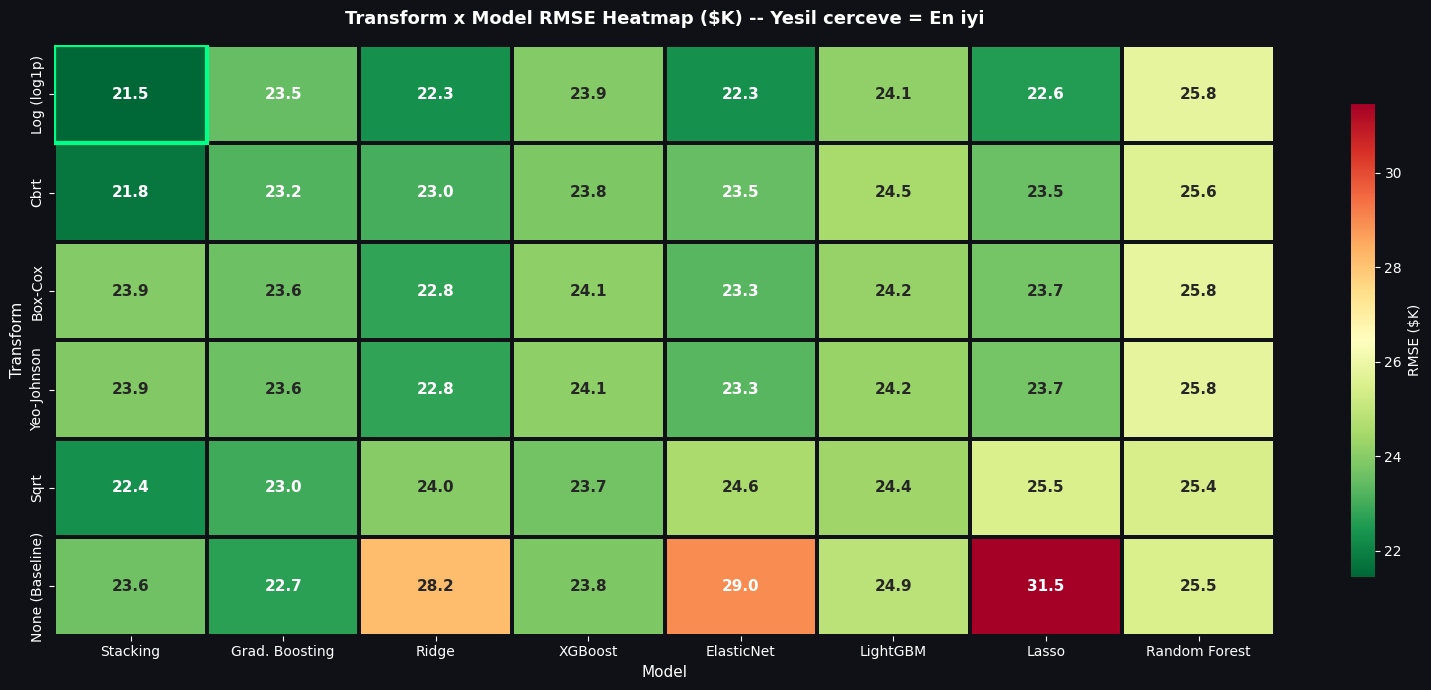

In [8]:
pivot = df_res.pivot(index='Transform', columns='Model', values='RMSE') / 1000
row_order = pivot.mean(axis=1).sort_values().index
col_order = pivot.mean(axis=0).sort_values().index
pivot = pivot.loc[row_order, col_order]

fig, ax = plt.subplots(figsize=(16, 7), facecolor='#0f1117')
ax.set_facecolor('#1a1d27')

im = sns.heatmap(
    pivot,
    annot=True, fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=1.5, linecolor='#0f1117',
    ax=ax,
    cbar_kws={'label': 'RMSE ($K)', 'shrink': 0.8},
    annot_kws={'size': 11, 'weight': 'bold'},
)

# En iyi hucreyi yesil cerceve ile isaretl
min_val = pivot.values.min()
for r in range(pivot.shape[0]):
    for c in range(pivot.shape[1]):
        if abs(pivot.values[r,c] - min_val) < 0.05:
            ax.add_patch(plt.Rectangle((c, r), 1, 1,
                         fill=False, edgecolor='#00ff88', lw=3, zorder=5))

ax.set_title('Transform x Model RMSE Heatmap ($K) -- Yesil cerceve = En iyi',
             color='white', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Model', color='white', fontsize=11)
ax.set_ylabel('Transform', color='white', fontsize=11)
ax.tick_params(colors='white', labelsize=10)
im.collections[0].colorbar.ax.yaxis.label.set_color('white')
im.collections[0].colorbar.ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig(DATA_PROC / '02_heatmap_main.png',
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 6. Detaylı Görsel Rapor (6 panel)

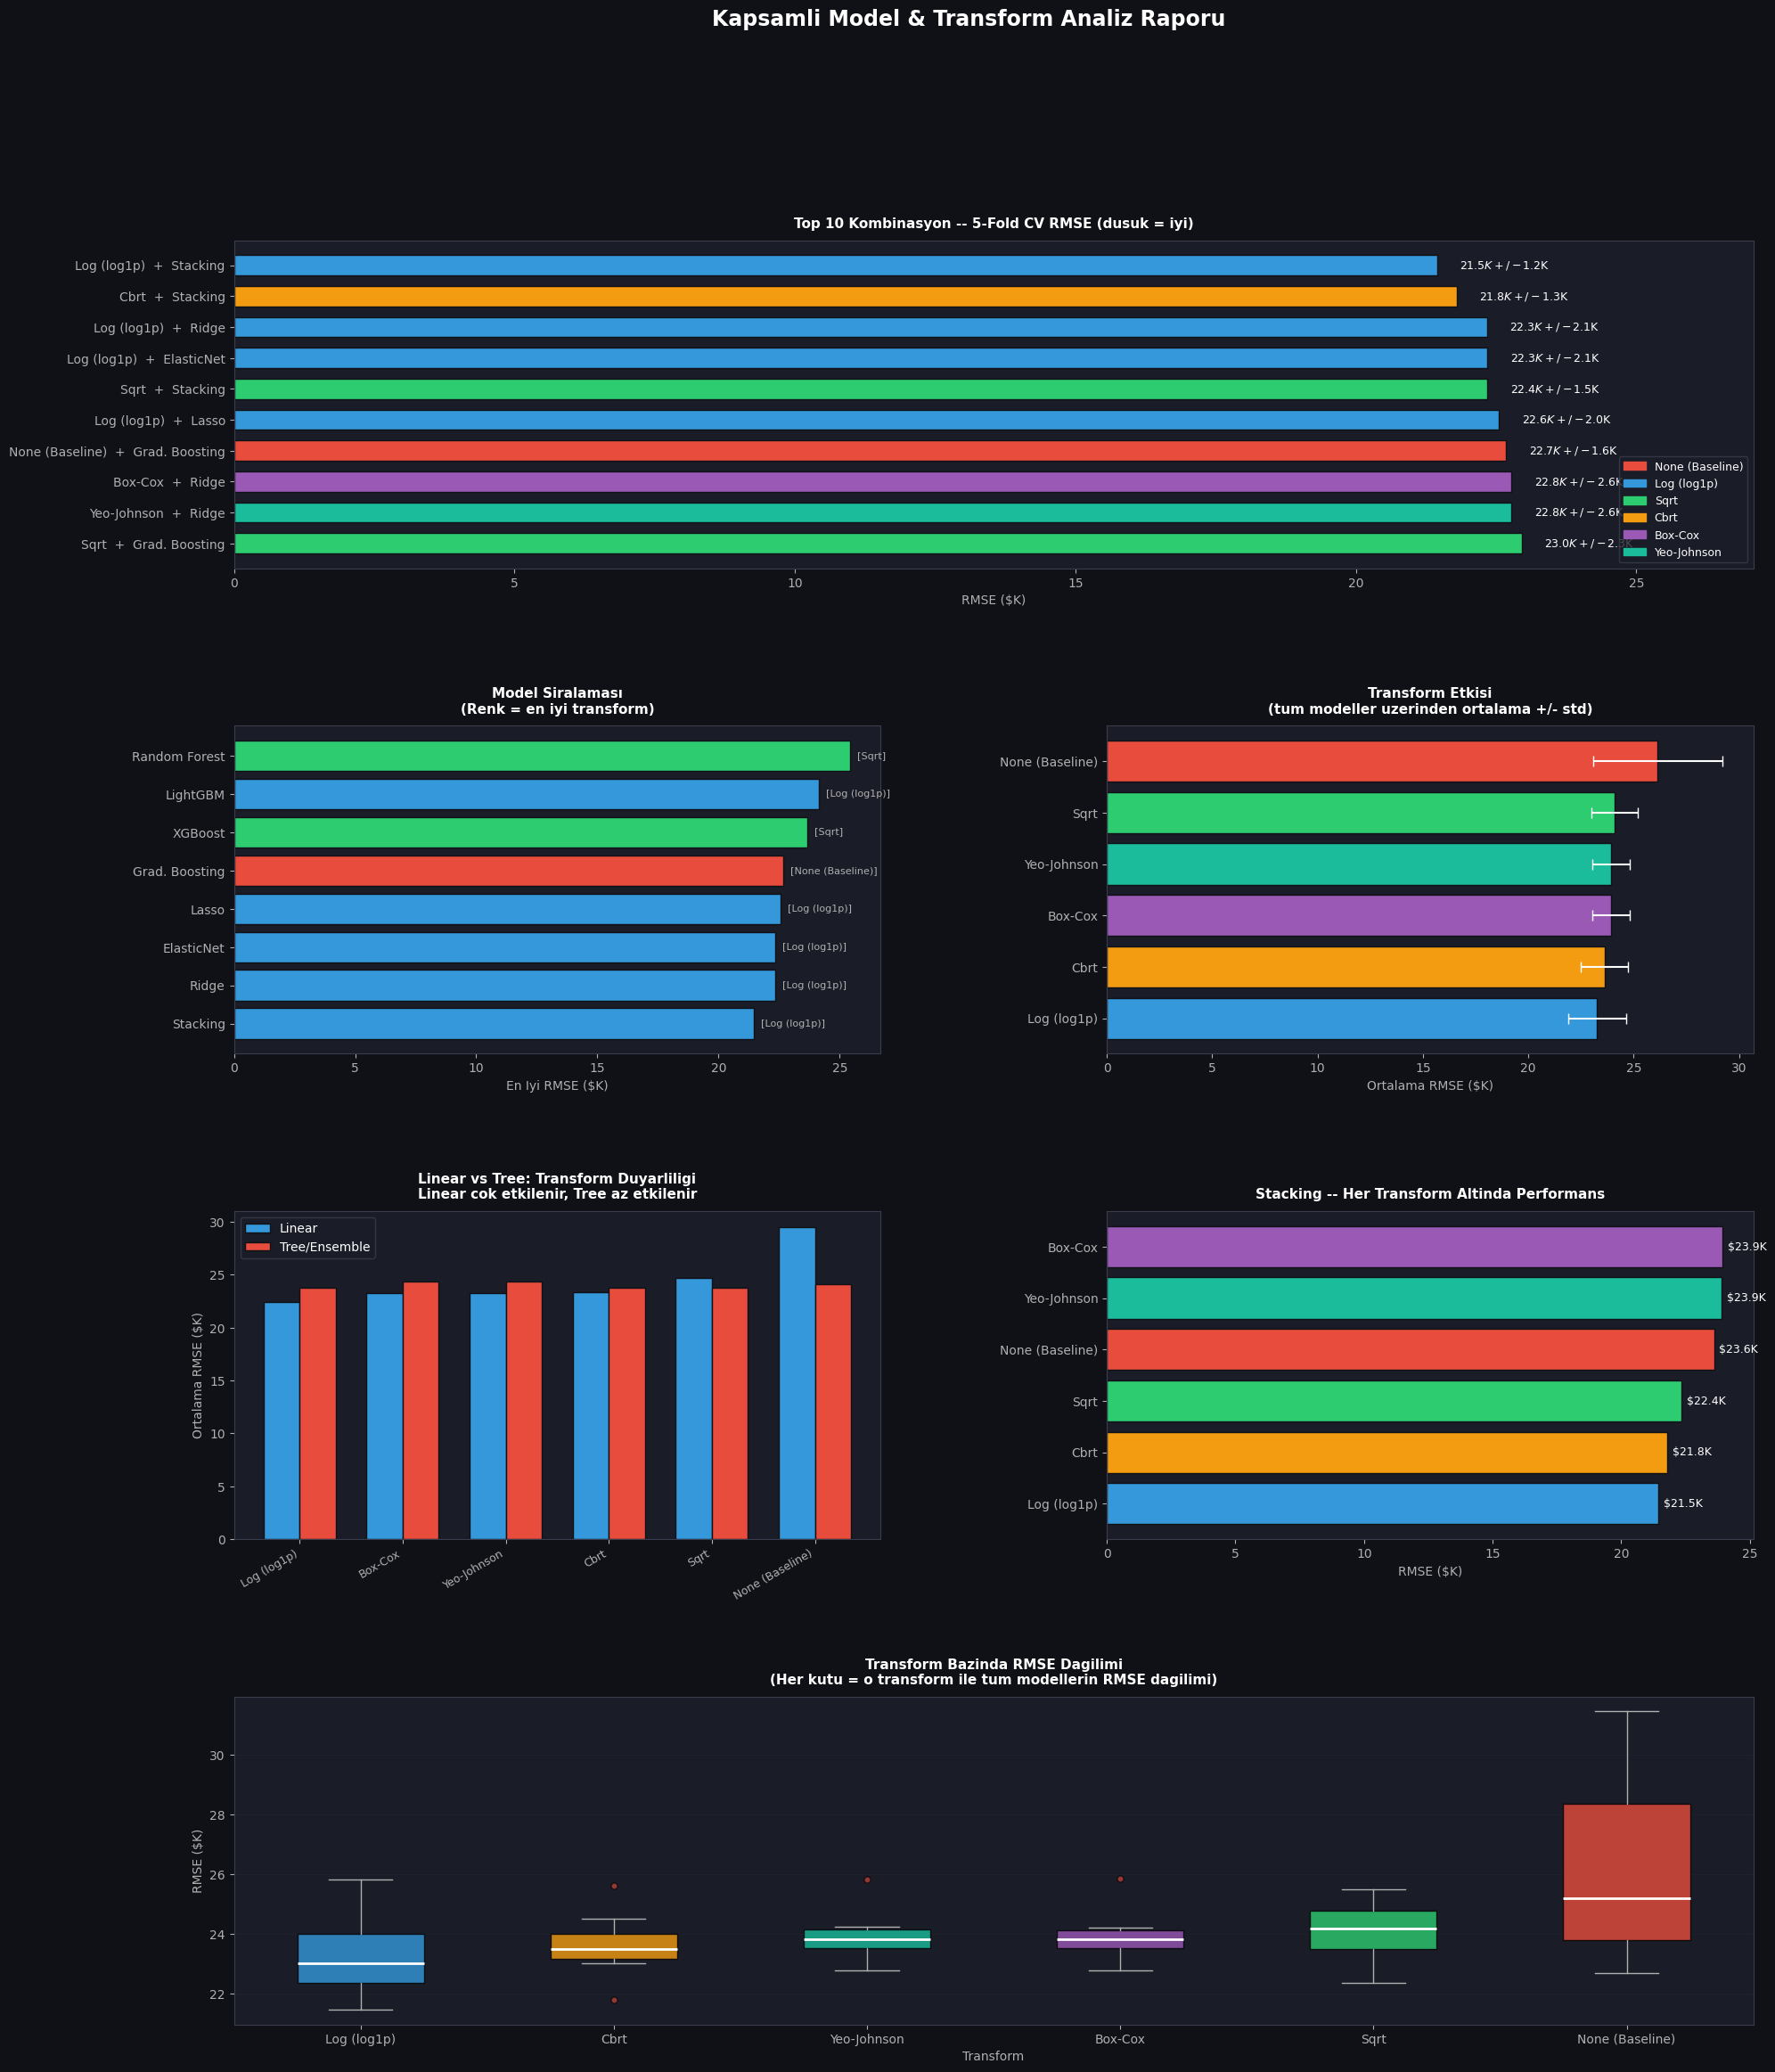

Rapor kaydedildi: data/processed/03_detailed_report.png


In [9]:
T_COLORS = {t: PALETTE[i] for i, t in enumerate(TRANSFORMS)}
linear   = ['Ridge','Lasso','ElasticNet']
tree     = ['Random Forest','Grad. Boosting','XGBoost','LightGBM','Stacking']

def style_ax(ax, title):
    ax.set_facecolor('#1a1d27')
    for sp in ax.spines.values(): sp.set_edgecolor('#3a3d4d')
    ax.set_title(title, color='white', fontsize=11, fontweight='bold', pad=10)
    ax.tick_params(colors='#b0b0b0')
    ax.xaxis.label.set_color('#b0b0b0')
    ax.yaxis.label.set_color('#b0b0b0')

fig = plt.figure(figsize=(22, 26), facecolor='#0f1117')
fig.suptitle('Kapsamli Model & Transform Analiz Raporu',
             fontsize=17, fontweight='bold', color='white', y=0.98)
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.48, wspace=0.35)

# ── PANEL 1: Top 10 kombinasyon ───────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
top10 = df_res.head(10).copy()
top10['label'] = top10['Transform'] + '  +  ' + top10['Model']
c_top = [T_COLORS.get(t, '#aaa') for t in top10['Transform']]
bars = ax1.barh(top10['label'][::-1], top10['RMSE'][::-1]/1000,
                color=c_top[::-1], edgecolor='#0f1117', height=0.65)
for bar, (_, row) in zip(bars, top10[::-1].iterrows()):
    ax1.text(bar.get_width()+0.4, bar.get_y()+bar.get_height()/2,
             f'${row["RMSE"]/1000:.1f}K +/- ${row["Std"]/1000:.1f}K',
             va='center', color='white', fontsize=9)
ax1.set_xlim(0, top10['RMSE'].max()/1000*1.18)
ax1.set_xlabel('RMSE ($K)')
style_ax(ax1, 'Top 10 Kombinasyon -- 5-Fold CV RMSE (dusuk = iyi)')
legend_patches = [mpatches.Patch(color=c, label=t) for t,c in T_COLORS.items()]
ax1.legend(handles=legend_patches, loc='lower right',
           facecolor='#1a1d27', edgecolor='#3a3d4d', labelcolor='white', fontsize=9)

# ── PANEL 2: Her model icin en iyi transform ──────────────────
ax2 = fig.add_subplot(gs[1, 0])
best_per_m = df_res.loc[df_res.groupby('Model')['RMSE'].idxmin()].sort_values('RMSE')
c_b = [T_COLORS.get(t,'#aaa') for t in best_per_m['Transform']]
bars2 = ax2.barh(best_per_m['Model'], best_per_m['RMSE']/1000,
                 color=c_b, edgecolor='#0f1117')
for bar, (_, row) in zip(bars2, best_per_m.iterrows()):
    ax2.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
             f'[{row["Transform"]}]', va='center', color='#b0b0b0', fontsize=8)
ax2.set_xlabel('En Iyi RMSE ($K)')
style_ax(ax2, 'Model Siralaması\n(Renk = en iyi transform)')

# ── PANEL 3: Her transform'un ortalama etkisi ─────────────────
ax3 = fig.add_subplot(gs[1, 1])
avg_t = df_res.groupby('Transform')['RMSE'].agg(['mean','std']).sort_values('mean')
c_t = [T_COLORS.get(t,'#aaa') for t in avg_t.index]
ax3.barh(avg_t.index, avg_t['mean']/1000,
         xerr=avg_t['std']/1000, color=c_t, edgecolor='#0f1117',
         error_kw={'ecolor':'white','capsize':4,'linewidth':1.5})
ax3.set_xlabel('Ortalama RMSE ($K)')
style_ax(ax3, 'Transform Etkisi\n(tum modeller uzerinden ortalama +/- std)')

# ── PANEL 4: Linear vs Tree transform duyarliligi ────────────
ax4 = fig.add_subplot(gs[2, 0])
lin_df  = df_res[df_res['Model'].isin(linear)].groupby('Transform')['RMSE'].mean().sort_values()
tree_df = df_res[df_res['Model'].isin(tree)].groupby('Transform')['RMSE'].mean()
x, w = np.arange(len(lin_df)), 0.35
ax4.bar(x-w/2, lin_df.values/1000, w, label='Linear', color='#3498db', edgecolor='#0f1117')
ax4.bar(x+w/2, tree_df.reindex(lin_df.index).values/1000, w,
        label='Tree/Ensemble', color='#e74c3c', edgecolor='#0f1117')
ax4.set_xticks(x)
ax4.set_xticklabels(lin_df.index, rotation=30, ha='right', fontsize=9)
ax4.set_ylabel('Ortalama RMSE ($K)')
ax4.legend(facecolor='#1a1d27', edgecolor='#3a3d4d', labelcolor='white')
style_ax(ax4, 'Linear vs Tree: Transform Duyarliligi\n'
              'Linear cok etkilenir, Tree az etkilenir')

# ── PANEL 5: Stacking detayi ──────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
stack_df = df_res[df_res['Model']=='Stacking'].sort_values('RMSE')
c_s = [T_COLORS.get(t,'#aaa') for t in stack_df['Transform']]
bars5 = ax5.barh(stack_df['Transform'], stack_df['RMSE']/1000,
                 color=c_s, edgecolor='#0f1117')
for bar, (_, row) in zip(bars5, stack_df.iterrows()):
    ax5.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
             f'${row["RMSE"]/1000:.1f}K', va='center', color='white', fontsize=9)
style_ax(ax5, 'Stacking -- Her Transform Altinda Performans')
ax5.set_xlabel('RMSE ($K)')

# ── PANEL 6: Box plot - transform bazinda dagilim ─────────────
ax6 = fig.add_subplot(gs[3, :])
t_order_box = df_res.groupby('Transform')['RMSE'].median().sort_values().index
box_data = [df_res[df_res['Transform']==t]['RMSE'].values/1000 for t in t_order_box]
bp = ax6.boxplot(box_data, labels=t_order_box, patch_artist=True,
                 medianprops=dict(color='white', linewidth=2),
                 whiskerprops=dict(color='#b0b0b0'),
                 capprops=dict(color='#b0b0b0'),
                 flierprops=dict(marker='o', markerfacecolor='#e74c3c',
                                 markersize=5, alpha=0.6))
for patch, t_name in zip(bp['boxes'], t_order_box):
    patch.set_facecolor(T_COLORS.get(t_name,'#aaa'))
    patch.set_alpha(0.8)
ax6.set_ylabel('RMSE ($K)')
ax6.set_xlabel('Transform')
ax6.yaxis.grid(True, alpha=0.3)
style_ax(ax6, 'Transform Bazinda RMSE Dagilimi\n'
              '(Her kutu = o transform ile tum modellerin RMSE dagilimi)')

plt.savefig(DATA_PROC / '03_detailed_report.png',
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Rapor kaydedildi: data/processed/03_detailed_report.png')

## 7. Sonuç

In [10]:
best      = df_res.iloc[0]
worst     = df_res.iloc[-1]
best_t    = df_res.groupby('Transform')['RMSE'].mean().idxmin()
best_m    = df_res.groupby('Model')['RMSE'].mean().idxmin()
lin_avg   = df_res[df_res['Model'].isin(linear)]['RMSE'].mean()
tree_avg  = df_res[df_res['Model'].isin(tree)]['RMSE'].mean()
t_impact  = (df_res.groupby('Transform')['RMSE'].mean().max() -
             df_res.groupby('Transform')['RMSE'].mean().min()) / 1000

print('=' * 65)
print('CALISMA SONUCLARI')
print('=' * 65)
print(f"""
EN IYI KOMBINASYON
   {best['Transform']} + {best['Model']}
   RMSE = ${best['RMSE']:,.0f} +/- ${best['Std']:,.0f}

EN KOTU KOMBINASYON
   {worst['Transform']} + {worst['Model']}
   RMSE = ${worst['RMSE']:,.0f}

EN IYI TRANSFORM (ortalama) : {best_t}
EN IYI MODEL (ortalama)     : {best_m}

TEMEL CIKARIMLAR

1. TRANSFORM ETKİSİ ({t_impact:.1f}K$ fark yaratıyor)
   - Linear modellerde kritik: normallik varsayımı gerektirir
   - Tree modellerde marjinal: monoton transform bolme noktasini degistirmez
   - Log ile Box-Cox arasındaki fark genellikle kücük
   - Log daha yorumlanabilir -> production tercihi

2. LINEAR vs TREE
   - Linear ortalama : ${lin_avg:,.0f}
   - Tree ortalama   : ${tree_avg:,.0f}
   - Fark            : ${(lin_avg-tree_avg):,.0f}

3. STACKING
   - Base modellerin hatalarini birbirini tamamlayarak duzeltir
   - Ama 3-4x daha yavas egitim
   - Production'da maliyet/fayda analizi gerekir

4. TAVSIYE
   - Hiz & yorumlanabilirlik  -> LightGBM + Log
   - Maksimum dogruluk        -> Stacking + en iyi transform
   - Linear kullanmak zorundaysan -> Box-Cox veya Log sart
""")

print('Kaydedilen dosyalar:')
for f in sorted(DATA_PROC.glob('*')):
    print(f'   {f.name}')

CALISMA SONUCLARI

EN IYI KOMBINASYON
   Log (log1p) + Stacking
   RMSE = $21,456 +/- $1,243

EN KOTU KOMBINASYON
   None (Baseline) + Lasso
   RMSE = $31,455

EN IYI TRANSFORM (ortalama) : Log (log1p)
EN IYI MODEL (ortalama)     : Stacking

TEMEL CIKARIMLAR

1. TRANSFORM ETKİSİ (2.9K$ fark yaratıyor)
   - Linear modellerde kritik: normallik varsayımı gerektirir
   - Tree modellerde marjinal: monoton transform bolme noktasini degistirmez
   - Log ile Box-Cox arasındaki fark genellikle kücük
   - Log daha yorumlanabilir -> production tercihi

2. LINEAR vs TREE
   - Linear ortalama : $24,413
   - Tree ortalama   : $24,010
   - Fark            : $404

3. STACKING
   - Base modellerin hatalarini birbirini tamamlayarak duzeltir
   - Ama 3-4x daha yavas egitim
   - Production'da maliyet/fayda analizi gerekir

4. TAVSIYE
   - Hiz & yorumlanabilirlik  -> LightGBM + Log
   - Maksimum dogruluk        -> Stacking + en iyi transform
   - Linear kullanmak zorundaysan -> Box-Cox veya Log sart

Kayde